## Example the correction result

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def show_distribution_log_scale(array, title):
	fig, ax = plt.subplots(figsize=(8, 4))
	ax.hist(array.ravel(), bins=1000, color='gray')
	ax.set_title(title)
	ax.set_xlabel('Pixel Intensity')
	ax.set_ylabel('Frequency')
	ax.set_yscale('log')
	ax.grid(False)
	plt.show()

def img_show(array, title):
	# Calculate mean along each axis
	mean_x_axis = np.mean(array, axis=0) # Mean along columns
	mean_y_axis = np.mean(array, axis=1) # Mean along rows

	# Create subplots
	fig, ax = plt.subplots(1, 3, figsize=(12, 4)) # One row, three columns

	# Plot the image
	im = ax[0].imshow(array, cmap='rainbow') # Display image in 'rainbow' colormap
	ax[0].set_title('Original Image')
	ax[0].set_xlabel('X-axis (Columns)')
	ax[0].set_ylabel('Y-axis (Rows)')
	fig.colorbar(im, ax=ax[0], orientation='vertical', label='Intensity')


	# Plot the mean along the X-axis
	ax[1].plot(mean_x_axis)
	ax[1].set_title('Mean along X-axis')
	ax[1].set_xlabel('X-axis (Columns)')
	ax[1].set_ylabel('Mean Intensity')

	# Plot the mean along the Y-axis
	ax[2].plot(mean_y_axis, range(len(mean_y_axis))) # Plot against y-axis indices
	ax[2].set_title('Mean along Y-axis')
	ax[2].set_xlabel('Mean Intensity')
	ax[2].set_ylabel('Y-axis (Rows)')
	ax[2].invert_yaxis() # Invert y-axis to match image orientation

	plt.suptitle(title, fontsize=16)
	plt.tight_layout()
	plt.show()




## correction algorithm

In [6]:
def estimate_gain_org(array_this, array_correction):
    eps = 1e-12
    denom = np.sum((array_this * array_correction) ** 2) + eps
    numer = np.sum(array_this * array_correction) * 50000.0
    return numer / denom

def estimate_gain(array_this, array_correction):
    eps = 1e-12
    
    # Compute element-wise products
    products = array_this * array_correction
    
    # Flatten to 1D for processing
    flat_products = products.flatten()
    
    if len(flat_products) == 0:
        return 0.0  # Return 0 for empty arrays
    
    # Get absolute values and sort them in descending order
    abs_products = np.abs(flat_products)
    sorted_indices = np.argsort(abs_products)[::-1]  # Sort in descending order
    
    # Take the first half (largest elements)
    n_elements = len(flat_products)
    n_full_intensity = max(1, n_elements // 2)  # Ensure at least 1 element
    n_too_big_outliers = n_elements // 10
    
    # Get indices of the largest half elements
    largest_indices = sorted_indices[n_too_big_outliers:n_full_intensity]
    
    # Extract the largest half elements
    filtered_products = flat_products[largest_indices]
    
    # Compute gain
    denom = np.sum(filtered_products ** 2) + eps
    numer = np.sum(filtered_products) * 50000.0
    
    return numer / denom



def correct_image(array_this, array_correction):
    gain = estimate_gain(array_this, array_correction)
    array_corrected = array_this * array_correction * gain
    return array_corrected

## Show the correction array

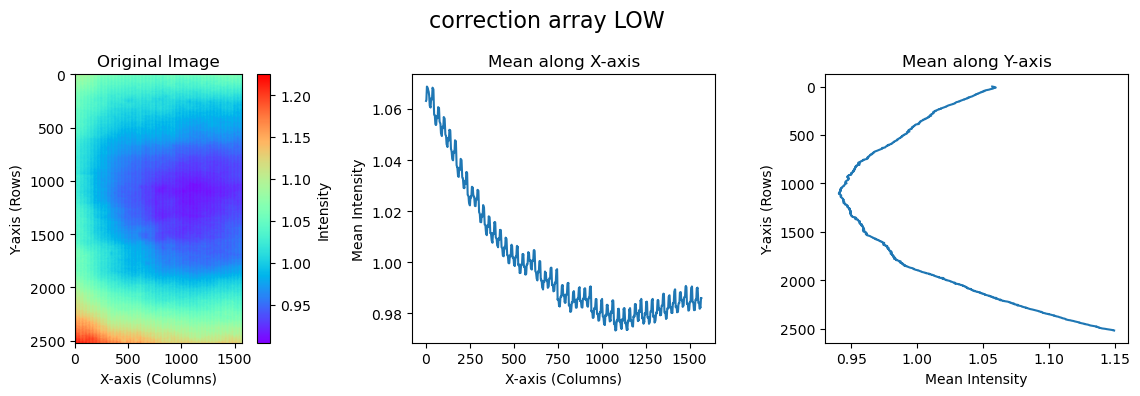

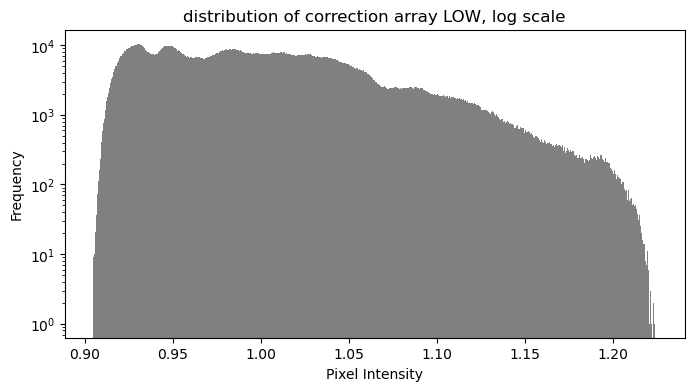

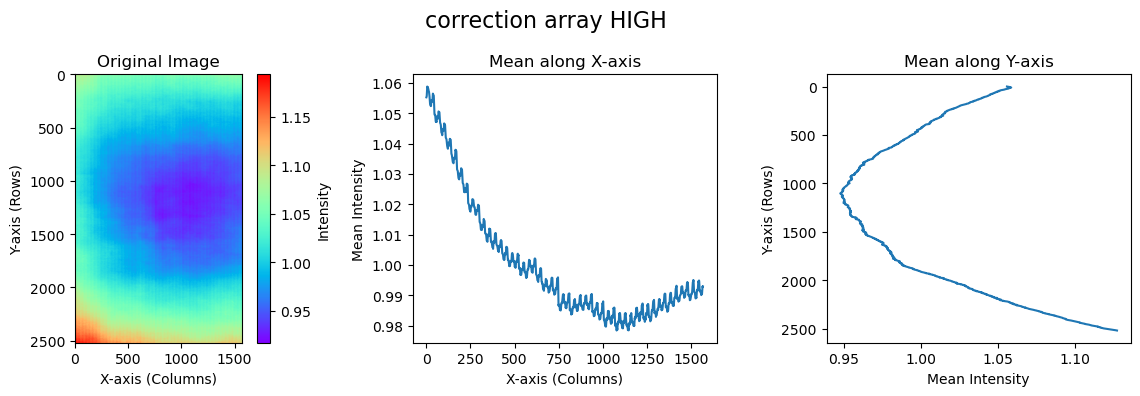

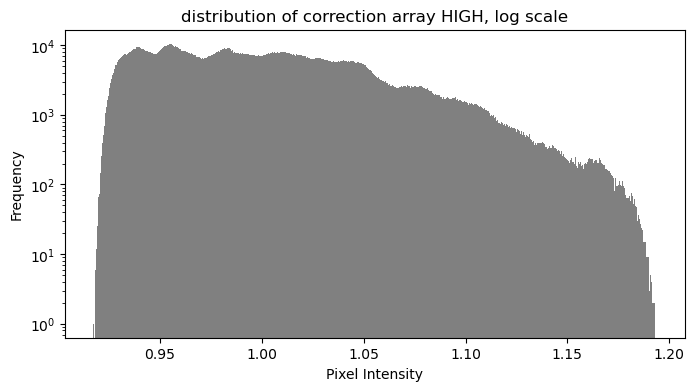

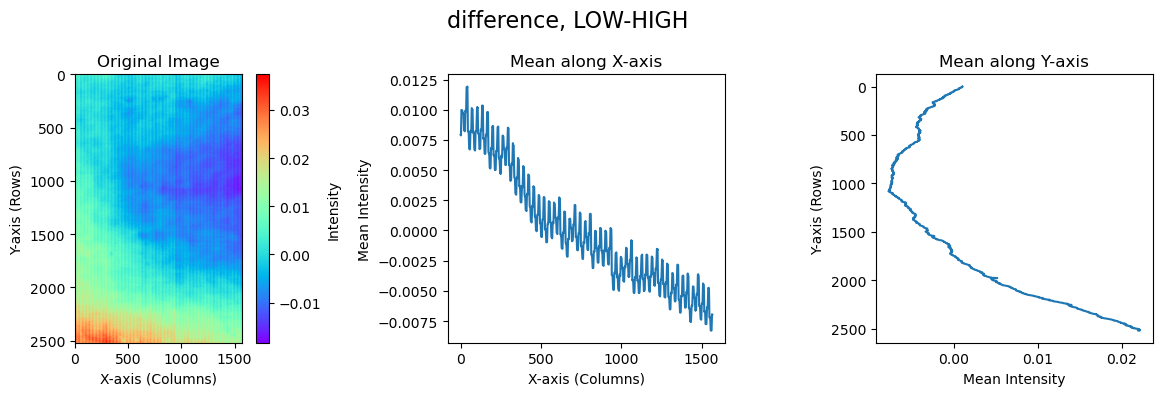

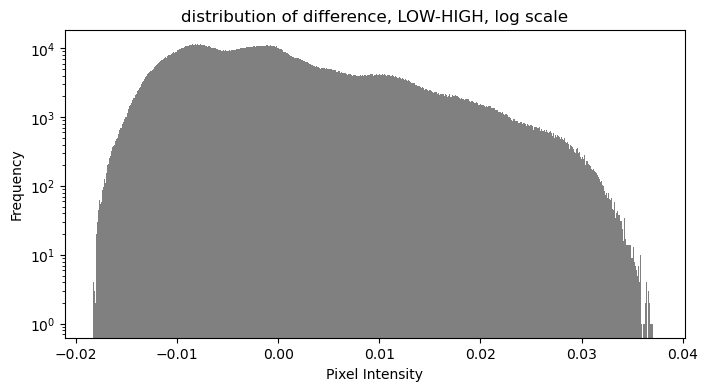

In [7]:
IMAGE_HEIGHT = 2560 - 20 - 20
IMAGE_WIDTH = 2048 - 20 - 460

array_correction_low = np.loadtxt("correction_low.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
array_correction_high = np.loadtxt("correction_high.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_correction_low, "correction array LOW")
show_distribution_log_scale(array_correction_low, "distribution of correction array LOW, log scale")
img_show(array_correction_high, "correction array HIGH")
show_distribution_log_scale(array_correction_high, "distribution of correction array HIGH, log scale")

array_difference = array_correction_low - array_correction_high
img_show(array_difference, "difference, LOW-HIGH")
show_distribution_log_scale(array_difference, "distribution of difference, LOW-HIGH, log scale")


## Show example corrected image

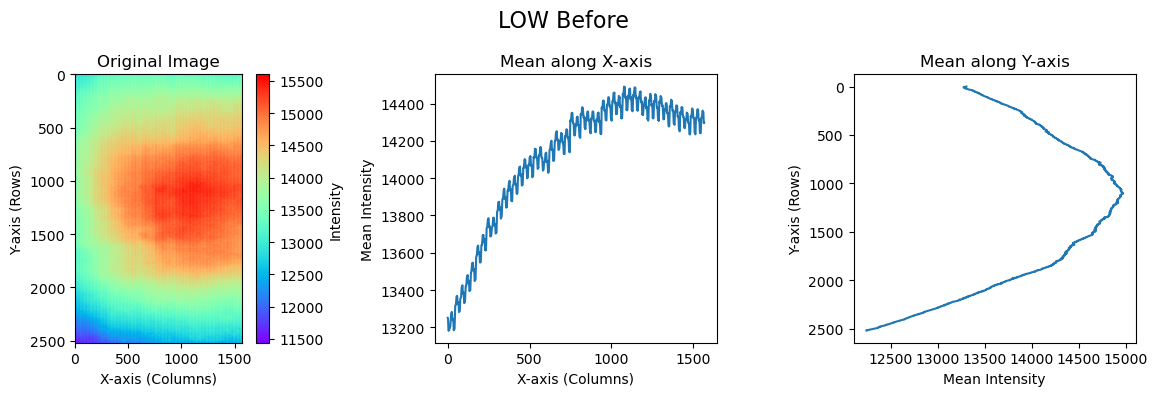

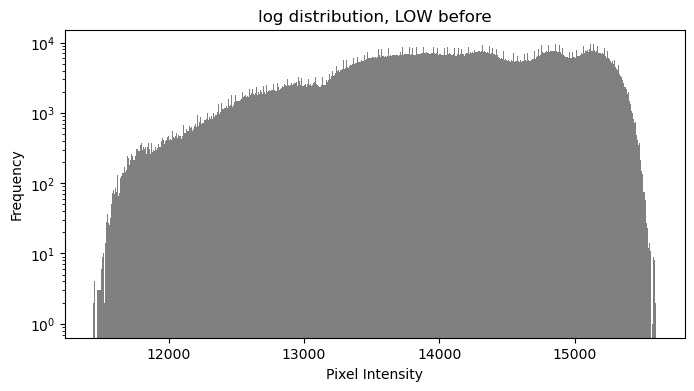

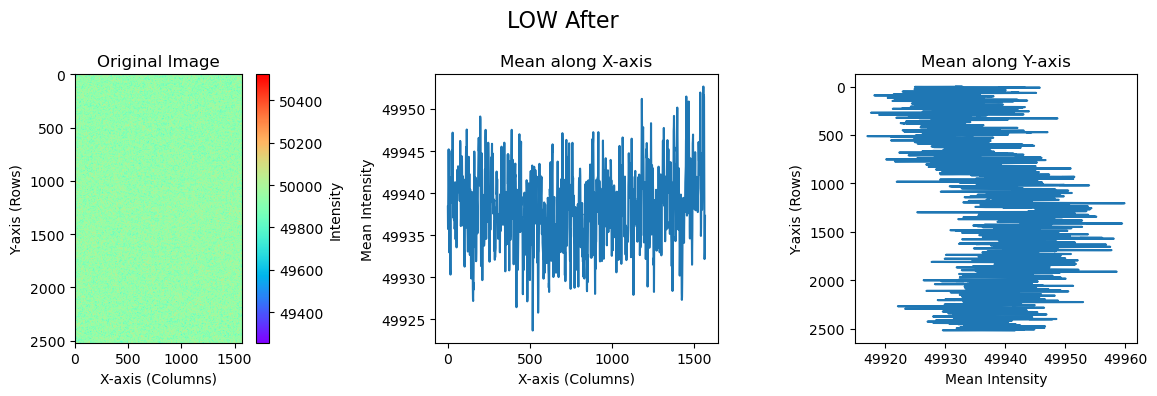

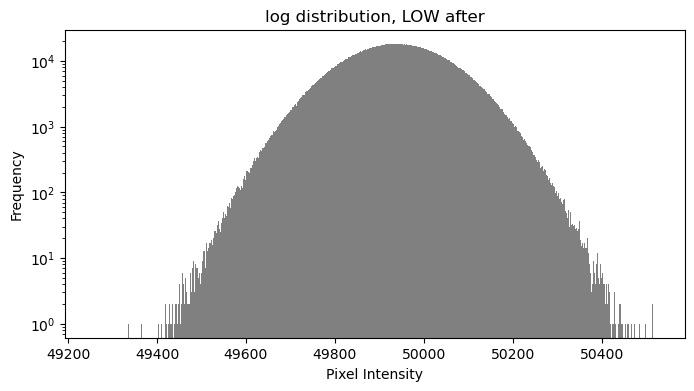

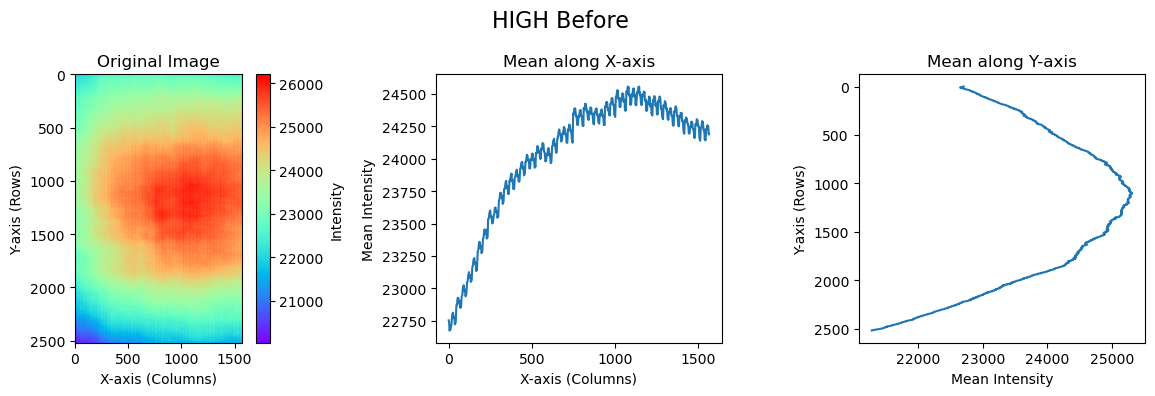

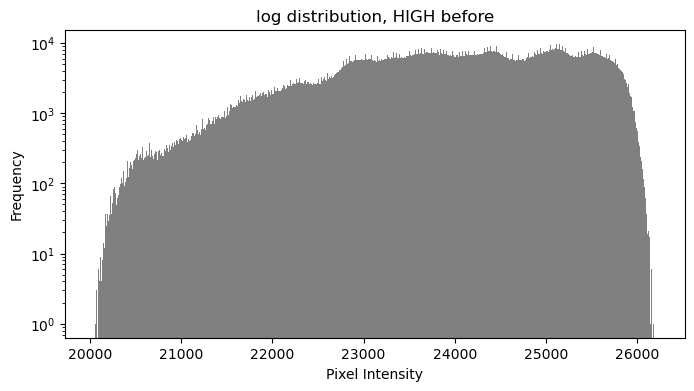

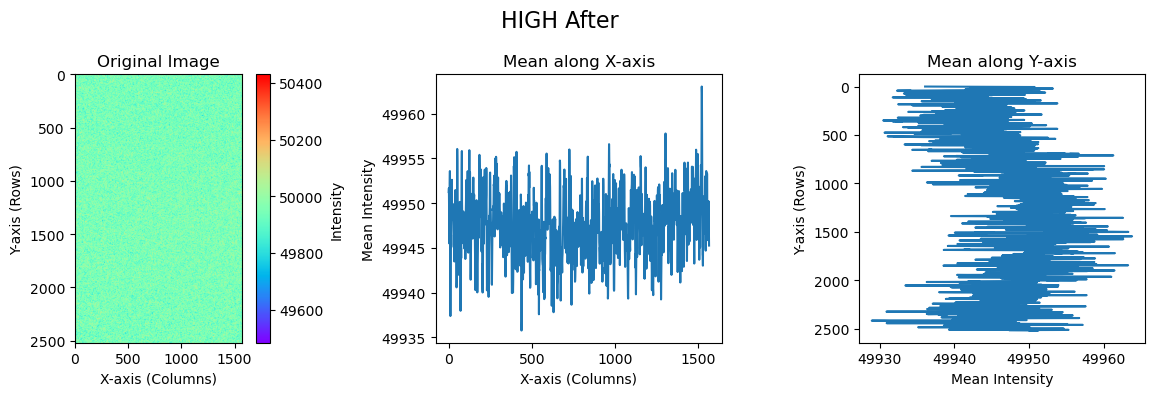

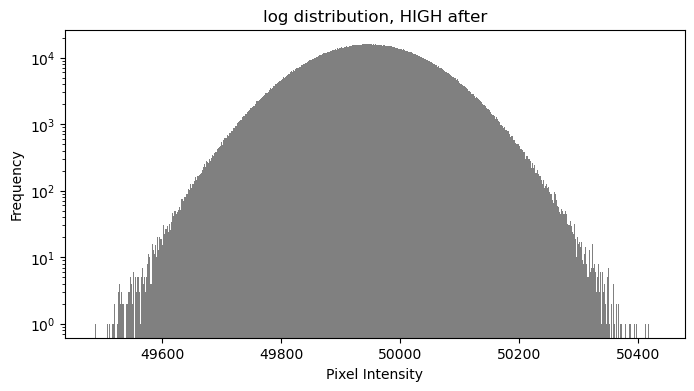

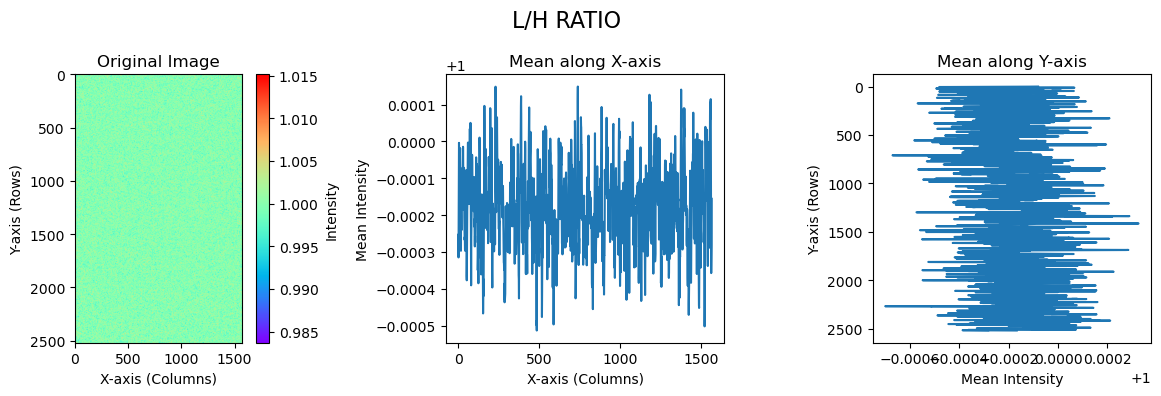

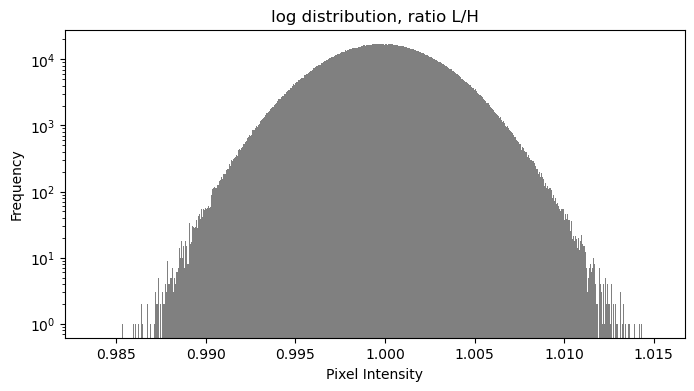

In [ ]:

sample = "39"

raw_file_low = f"output/empty/{sample}.raw.low"
raw_file_high = f"output/empty/{sample}.raw.high"

array_low_before = np.fromfile(raw_file_low, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_low_before, "LOW Before")
show_distribution_log_scale(array_low_before, "log distribution, LOW before")

array_low_after = correct_image(array_low_before, array_correction_low)

img_show(array_low_after, "LOW After")
show_distribution_log_scale(array_low_after, "log distribution, LOW after")

array_high_before = np.fromfile(raw_file_high, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_high_before, "HIGH Before")
show_distribution_log_scale(array_high_before, "log distribution, HIGH before")

array_high_after = correct_image(array_high_before, array_correction_high)

img_show(array_high_after, "HIGH After")
show_distribution_log_scale(array_high_after, "log distribution, HIGH after")

array_ratio_low_over_high = array_low_after / array_high_after

img_show(array_ratio_low_over_high, "L/H RATIO")
show_distribution_log_scale(array_ratio_low_over_high, "log distribution, ratio L/H")


In [ ]:
list_sequence = list(dic_off_pair.keys())
array_learning = np.array([array_mean_low_corner, array_mean_high_corner, array_mean_low_center, array_mean_high_center])
array_learning = array_learning.T  # Transpose to have each row as a sequence
np.savetxt("array_learning.csv", array_learning, delimiter=",", fmt="%7.2f")

array_mean_low_corner = np.array(array_mean_low_corner)
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].scatter(array_mean_low_corner, array_mean_low_center, s=5)
ax[0].set_title("Mean Low Corner vs Mean Low Center")
ax[0].set_xlabel("Mean Low Corner")
ax[0].set_ylabel("Mean Low Center")
ax[0].grid()

ax[1].scatter(array_mean_high_corner, array_mean_high_center, s=5)
ax[1].set_title("Mean High Corner vs Mean High Center")
ax[1].set_xlabel("Mean High Corner")
ax[1].set_ylabel("Mean High Center")
ax[1].grid()

plt.tight_layout()
plt.show()